# Traffic Demand Prediction Using LightGBM and XGBoost

## Objective

The objective of this project is to predict traffic demand using historical weather and traffic information. Multiple machine learning models are trained and compared to identify the most accurate approach.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [6]:
print(df.shape)

df.info()

(48204, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


## Missing Value Analysis

In [7]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [8]:
df['holiday'] = df['holiday'].fillna('No Holiday')

## Feature Engineering

In [9]:
df['date_time'] = pd.to_datetime(df['date_time'])

In [10]:
df['year'] = df['date_time'].dt.year
df['month'] = df['date_time'].dt.month
df['day'] = df['date_time'].dt.day
df['hour'] = df['date_time'].dt.hour
df['dayofweek'] = df['date_time'].dt.dayofweek

In [11]:
df['rush_hour'] = df['hour'].apply(
    lambda x: 1 if x in [7,8,9,16,17,18] else 0
)

In [12]:
df['weekend'] = df['dayofweek'].apply(
    lambda x: 1 if x >= 5 else 0
)

In [13]:
le = LabelEncoder()

df['holiday'] = le.fit_transform(df['holiday'])

df['weather_main'] = le.fit_transform(
    df['weather_main']
)

df['weather_description'] = le.fit_transform(
    df['weather_description']
)

In [14]:
df.drop('date_time', axis=1, inplace=True)

In [15]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,year,month,day,hour,dayofweek,rush_hour,weekend
0,7,288.28,0.0,0.0,40,1,24,5545,2012,10,2,9,1,1,0
1,7,289.36,0.0,0.0,75,1,2,4516,2012,10,2,10,1,0,0
2,7,289.58,0.0,0.0,90,1,19,4767,2012,10,2,11,1,0,0
3,7,290.13,0.0,0.0,90,1,19,5026,2012,10,2,12,1,0,0
4,7,291.14,0.0,0.0,75,1,2,4918,2012,10,2,13,1,0,0


In [16]:
X = df.drop('traffic_volume', axis=1)

y = df['traffic_volume']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [19]:
print("MAE:", mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2:",
      r2_score(y_test, rf_pred))

MAE: 201.52521626387306
RMSE: 370.1190095005983
R2: 0.965350294327679


In [20]:
print(df.shape)

(48204, 15)


In [21]:
print("R2:", r2_score(y_test, rf_pred))

R2: 0.965350294327679


## XGBoost Regressor

XGBoost is an advanced gradient boosting algorithm that often provides superior predictive performance for tabular datasets.

In [22]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [23]:
print("MAE:",
      mean_absolute_error(y_test, xgb_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("R2:",
      r2_score(y_test, xgb_pred))

MAE: 210.0403095409962
RMSE: 347.42404616613527
R2: 0.9694693088531494


## LightGBM Regressor

LightGBM is a gradient boosting framework optimized for speed and high predictive performance.

In [24]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 689
[LightGBM] [Info] Number of data points in the train set: 38563, number of used features: 14
[LightGBM] [Info] Start training from score 3256.314991


In [25]:
print("MAE:",
      mean_absolute_error(y_test, lgbm_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lgbm_pred)))

print("R2:",
      r2_score(y_test, lgbm_pred))

MAE: 198.63109938124163
RMSE: 315.60162398569264
R2: 0.9748061101665862


## Ensemble Model

Predictions from LightGBM and XGBoost are combined to improve overall accuracy.

In [26]:
ensemble_pred = (
    0.55 * lgbm_pred
    +
    0.45 * xgb_pred
)

In [27]:
print("MAE:",
      mean_absolute_error(y_test, ensemble_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, ensemble_pred)))

print("R2:",
      r2_score(y_test, ensemble_pred))

MAE: 198.88156033832863
RMSE: 323.9996862679061
R2: 0.9734474676429109


In [28]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                Feature  Importance
10                 hour    0.819657
11            dayofweek    0.059869
13              weekend    0.050112
1                  temp    0.019514
9                   day    0.016264
8                 month    0.010710
7                  year    0.005976
12            rush_hour    0.005734
6   weather_description    0.003388
5          weather_main    0.003182
4            clouds_all    0.003179
2               rain_1h    0.002327
3               snow_1h    0.000060
0               holiday    0.000028


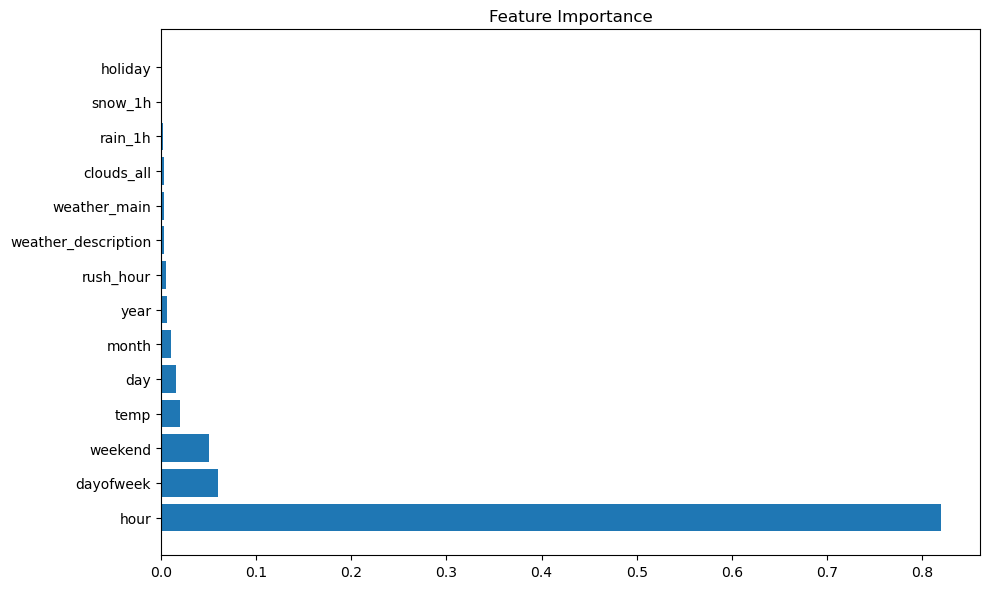

In [29]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

# Model Comparison

The performance of four machine learning models was evaluated:

| Model | R² Score |
|--------|----------|
| Random Forest | 0.9653 |
| XGBoost | 0.9695 |
| Ensemble Model | 0.9734 |
| LightGBM | 0.9748 |

Among all models, LightGBM achieved the highest R² score and demonstrated the strongest predictive capability for traffic demand forecasting.

# Conclusion

A Traffic Demand Prediction System was successfully developed using weather and temporal traffic data.

Feature engineering techniques such as rush-hour detection, weekend identification, and date-time decomposition significantly improved model performance.

Among all evaluated models, LightGBM produced the best results with an R² score of 0.9748, making it the preferred model for deployment in intelligent transportation systems.

In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                Feature  Importance
10                 hour        1222
9                   day        1077
1                  temp         861
11            dayofweek         837
8                 month         696
7                  year         527
12            rush_hour         176
4            clouds_all         156
2               rain_1h         150
5          weather_main         150
6   weather_description         116
0               holiday          18
3               snow_1h          14
13              weekend           0


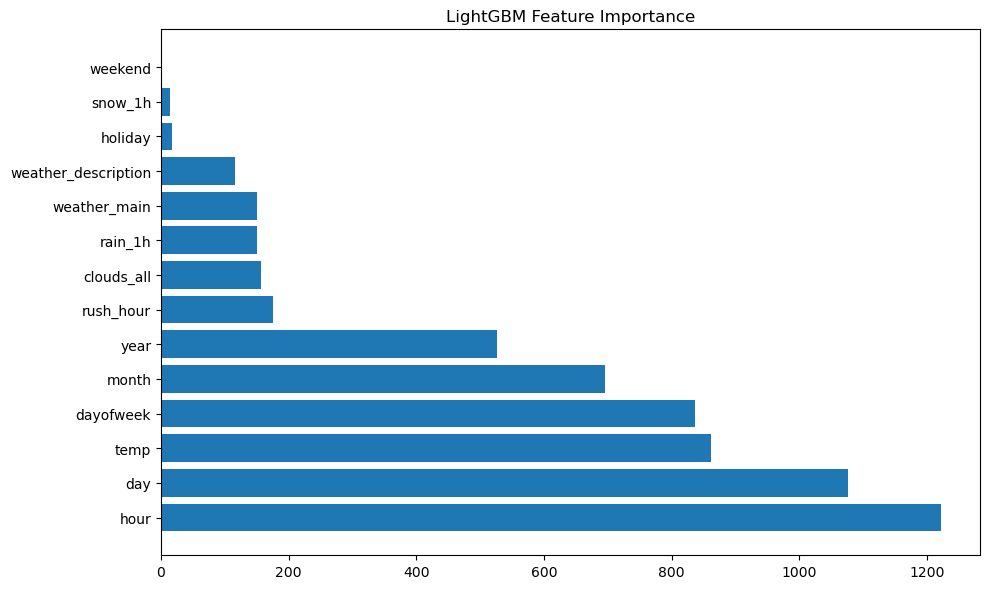

In [31]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("LightGBM Feature Importance")

plt.tight_layout()

plt.show()

In [32]:
import joblib

joblib.dump(lgbm, "traffic_model.pkl")

['traffic_model.pkl']

In [33]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [34]:
print(X.columns.tolist())

['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'year', 'month', 'day', 'hour', 'dayofweek', 'rush_hour', 'weekend']


In [35]:
import joblib

joblib.dump(lgbm, "traffic_model.pkl")

['traffic_model.pkl']

In [36]:
print(df["holiday"].unique())

[ 7  1 10  9  0  6 11  5  2  8  3  4]


In [37]:
print(df["weather_main"].unique())

[ 1  0  6  2  5  4  3 10  8  9  7]


In [38]:
print(df["weather_description"].unique())


[24  2 19 27  4 13 11 17  7  5 20  3 18  9 21 35 23 10  8 30 33  6 26 14
 12  0 36 22 31  1 37 34 16 32 29 25 15 28]
